# Data Mining Project — Apartment Price Prediction (Egypt)

## Student: Basmala Fatooh | ID: 220236852
## Data Source: [Dubizzle Egypt - Apartments for Sale](https://www.dubizzle.com.eg/properties/apartments-duplex-for-sale/)

### This notebook covers data preprocessing, exploratory analysis, and building a Linear Regression model to predict apartment prices in Egypt based on real listings scraped from Dubizzle.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
d_path = r"C:\Users\hp\Desktop\التنقيب على البيانات\web_\dubizzle_results1.csv" 
data_set = pd.read_csv(d_path)
data_set.head()

,title,price_egp,rooms,bathrooms,area_m2,link
0,شقة متشطبة جاهزة للسكن في Allegria اليجريا بدا...,7000000,4,4,198,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D8...
1,شقه للبيع استلام فورى في كمبوند سراي بسعر الكا...,5600000,3,2,164,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D9...
2,شقه للبيع في كمبوند سراي بسعر الكاش استلام فور...,5700000,3,2,169,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D9...
3,دوبلكس للبيع ياسمين ٦ التجمع الأول,16500000,5,5,440,https://www.dubizzle.com.eg/ad/%D8%AF%D9%88%D8...
4,للبيع شقة 175 متر في السياحية الشمالية الاولى ...,4285000,3,2,175,https://www.dubizzle.com.eg/ad/%D9%84%D9%84%D8...


# 1-Do a preprocessing steps 

### 1.1 Initial Data Inspection
## We first check the shape, structure, and basic statistics of the dataset to understand what we're working with before any cleaning.

In [3]:
data_set.shape

(494, 6)

In [4]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494 entries, 0 to 493
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      494 non-null    object
 1   price_egp  494 non-null    int64 
 2   rooms      494 non-null    int64 
 3   bathrooms  494 non-null    int64 
 4   area_m2    494 non-null    int64 
 5   link       494 non-null    object
dtypes: int64(4), object(2)
memory usage: 23.3+ KB


In [5]:
## We check for duplicate listings using the unique link of each ad as the identifier.
data_set.duplicated(subset=["link"]).sum()

np.int64(0)

In [6]:
data_set.describe()

,price_egp,rooms,bathrooms,area_m2
count,4.940000e+02,494.000000,494.000000,494.000000
mean,8.031850e+06,2.740891,2.451417,162.291498
std,5.536564e+06,0.824122,0.882940,62.012268
min,1.050000e+06,1.000000,1.000000,35.000000
25%,4.865750e+06,2.000000,2.000000,123.000000
50%,6.479108e+06,3.000000,2.000000,151.000000
75%,9.304000e+06,3.000000,3.000000,187.500000
max,5.000000e+07,10.000000,10.000000,552.000000


In [7]:
# Row has rooms=10, bathrooms=10, but area_m2=100 — physically unrealistic, checking if it's a scraping error or a real listing
data_set[data_set["rooms"] == 10]   

,title,price_egp,rooms,bathrooms,area_m2,link
314,بأوفر لايقارن فيلاا 1100م استلام فوري متشطبه 1...,38000000,10,10,100,https://www.dubizzle.com.eg/ad/%D8%A8%D8%A3%D9...


In [8]:
# Checking max price outlier — verified real (390m² luxury duplex)
data_set[data_set["price_egp"] == data_set["price_egp"].max()]

,title,price_egp,rooms,bathrooms,area_m2,link
331,دوبلكس بجاردن للبيع استلام فوري متشطب 390 م رو...,50000000,4,4,390,https://www.dubizzle.com.eg/ad/%D8%AF%D9%88%D8...


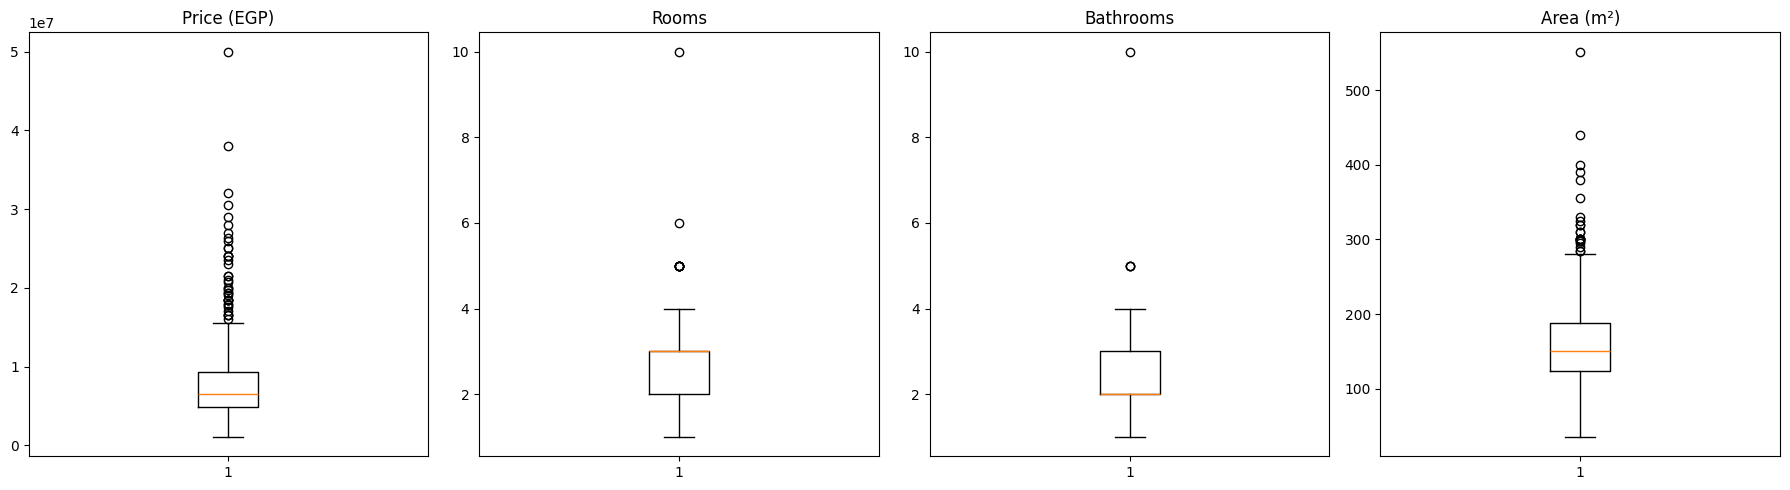

In [9]:
# Boxplots for each numeric column to visually spot outliers before deciding to remove them
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].boxplot(data_set["price_egp"])
axes[0].set_title("Price (EGP)")

axes[1].boxplot(data_set["rooms"])
axes[1].set_title("Rooms")

axes[2].boxplot(data_set["bathrooms"])
axes[2].set_title("Bathrooms")

axes[3].boxplot(data_set["area_m2"])
axes[3].set_title("Area (m²)")

plt.tight_layout()
plt.show()

In [10]:
data_set = data_set.drop(index=314)
data_set.shape   # Make sure it became 493 instead of 494

(493, 6)

## 2-Build a Linear Regression model using Sklearn library 

In [11]:
#define x and y
x = data_set[["rooms", "bathrooms", "area_m2"]]
y = data_set["price_egp"]

In [12]:
#Train Test Split
from sklearn.model_selection import train_test_split
x_tr, x_val, y_tr, y_val = train_test_split(x, y, train_size=0.8, random_state=42)

In [13]:
#Normalization 
x_tr_norm = (x_tr - x_tr.mean()) / x_tr.std()
x_val_norm = (x_val - x_tr.mean()) / x_tr.std()

In [14]:
# Traning LinearRegression Model
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(x_tr_norm, y_tr)
pred_1 = model_1.predict(x_val_norm)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluating Model 1 (baseline) on the validation set using MAE and R²
mae = mean_absolute_error(y_val, pred_1)
r2 = r2_score(y_val, pred_1)

In [16]:
print(f"MAE: {mae:,.2f}")
print(f"R²: {r2:.4f}")

MAE: 2,912,808.80
R²: 0.4113


### 2.2 Correlation Analysis
We examine the correlation between price and the base numeric features to understand which ones are the strongest linear predictors before engineering additional features.

In [17]:
data_set[["price_egp", "rooms", "bathrooms", "area_m2"]].corr()

,price_egp,rooms,bathrooms,area_m2
price_egp,1.000000,0.367824,0.484404,0.523060
rooms,0.367824,1.000000,0.713883,0.772585
bathrooms,0.484404,0.713883,1.000000,0.678447
area_m2,0.523060,0.772585,0.678447,1.000000


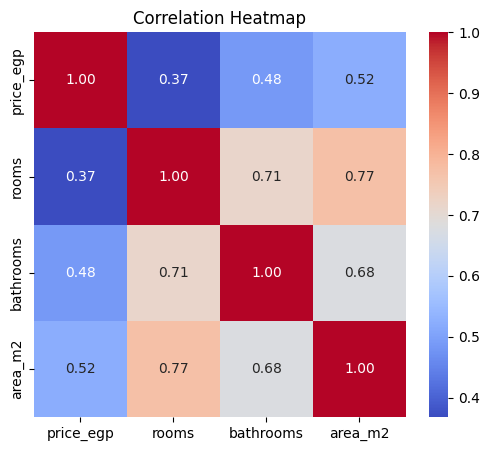

In [18]:
plt.figure(figsize=(6, 5))
sns.heatmap(data_set[["price_egp", "rooms", "bathrooms", "area_m2"]].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 3) Feature Engineering

We extract additional binary features from the listing title (`title`) using keyword matching in
both Arabic and English, since listings are written inconsistently in either language.

In [19]:
data_set["is_compound"] = data_set["title"].str.contains("كمبوند", na=False).astype(int)
data_set["is_compound"].value_counts()

is_compound
0    359
1    134
Name: count, dtype: int64

In [20]:
# هنا جربت لو بدي اكتب بالعربي والانجليزي هل بيفرق ولا لأ
data_set["is_compound"] = (
    data_set["title"].str.contains("كمبوند", na=False) |
    data_set["title"].str.contains("compound", case=False, na=False)
).astype(int)

In [21]:
data_set["is_compound"].value_counts()

is_compound
0    358
1    135
Name: count, dtype: int64

In [22]:
data_set["is_duplex"] = (
    data_set["title"].str.contains("دوبلكس", na=False) |
    data_set["title"].str.contains("duplex", case=False, na=False)
).astype(int)
data_set["is_duplex"].value_counts()

is_duplex
0    468
1     25
Name: count, dtype: int64

In [23]:
data_set["is_penthouse"] = (
    data_set["title"].str.contains("بنتهاوس", na=False) |
    data_set["title"].str.contains("penthouse", case=False, na=False)
).astype(int)
data_set["is_penthouse"].value_counts()

is_penthouse
0    473
1     20
Name: count, dtype: int64

In [24]:
data_set["is_finished"] = (
    data_set["title"].str.contains("متشطب", na=False) |
    data_set["title"].str.contains("finished", case=False, na=False)
).astype(int)

In [25]:
data_set["is_ready"] = (
    data_set["title"].str.contains("استلام فوري", na=False) |
    data_set["title"].str.contains("استلام فورى", na=False)
).astype(int)

In [26]:
data_set["has_view"] = (
    data_set["title"].str.contains("فيو", na=False) |
    data_set["title"].str.contains("view", case=False, na=False)
).astype(int)

In [27]:
data_set["is_luxury"] = (
    data_set["title"].str.contains("لوكس", na=False) |
    data_set["title"].str.contains("luxury", case=False, na=False)
).astype(int)

In [28]:
data_set["is_cash"] = data_set["title"].str.contains("كاش", na=False).astype(int)

In [29]:
data_set["has_discount"] = data_set["title"].str.contains("خصم", na=False).astype(int)

In [30]:
data_set["is_installment"] = (
    data_set["title"].str.contains("اقساط", na=False) |
    data_set["title"].str.contains("تقسيط", na=False) |
    data_set["title"].str.contains("مقدم", na=False)
).astype(int)

In [31]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 493 entries, 0 to 493
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           493 non-null    object
 1   price_egp       493 non-null    int64 
 2   rooms           493 non-null    int64 
 3   bathrooms       493 non-null    int64 
 4   area_m2         493 non-null    int64 
 5   link            493 non-null    object
 6   is_compound     493 non-null    int64 
 7   is_duplex       493 non-null    int64 
 8   is_penthouse    493 non-null    int64 
 9   is_finished     493 non-null    int64 
 10  is_ready        493 non-null    int64 
 11  has_view        493 non-null    int64 
 12  is_luxury       493 non-null    int64 
 13  is_cash         493 non-null    int64 
 14  has_discount    493 non-null    int64 
 15  is_installment  493 non-null    int64 
dtypes: int64(14), object(2)
memory usage: 65.5+ KB


In [32]:
# 1. We start with a default value
data_set["area"] = "unspecified"

# 2. I fill every area
data_set.loc[data_set["title"].str.contains("الشروق", na=False), "area"] = "El_Shorouk"
data_set.loc[data_set["title"].str.contains("مدينتي", na=False), "area"] = "Madinaty"
data_set.loc[data_set["title"].str.contains("الشيخ زايد|زايد", na=False), "area"] = "Sheikh_Zayed"
data_set.loc[data_set["title"].str.contains("القاهرة الجديدة|القاهره الجديده", na=False), "area"] = "New_Cairo"
data_set.loc[data_set["title"].str.contains("التجمع الخامس", na=False), "area"] = "Fifth_Settlement"

# 3. Let's look at the distribution before we convert to dummies
print(data_set["area"].value_counts())

area_dummies = pd.get_dummies(data_set["area"], prefix="area").astype(int)
data_set = pd.concat([data_set, area_dummies], axis=1)

area
unspecified         288
Fifth_Settlement    111
Madinaty             32
Sheikh_Zayed         26
El_Shorouk           21
New_Cairo            15
Name: count, dtype: int64


In [33]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 493 entries, 0 to 493
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  493 non-null    object
 1   price_egp              493 non-null    int64 
 2   rooms                  493 non-null    int64 
 3   bathrooms              493 non-null    int64 
 4   area_m2                493 non-null    int64 
 5   link                   493 non-null    object
 6   is_compound            493 non-null    int64 
 7   is_duplex              493 non-null    int64 
 8   is_penthouse           493 non-null    int64 
 9   is_finished            493 non-null    int64 
 10  is_ready               493 non-null    int64 
 11  has_view               493 non-null    int64 
 12  is_luxury              493 non-null    int64 
 13  is_cash                493 non-null    int64 
 14  has_discount           493 non-null    int64 
 15  is_installment         493 n

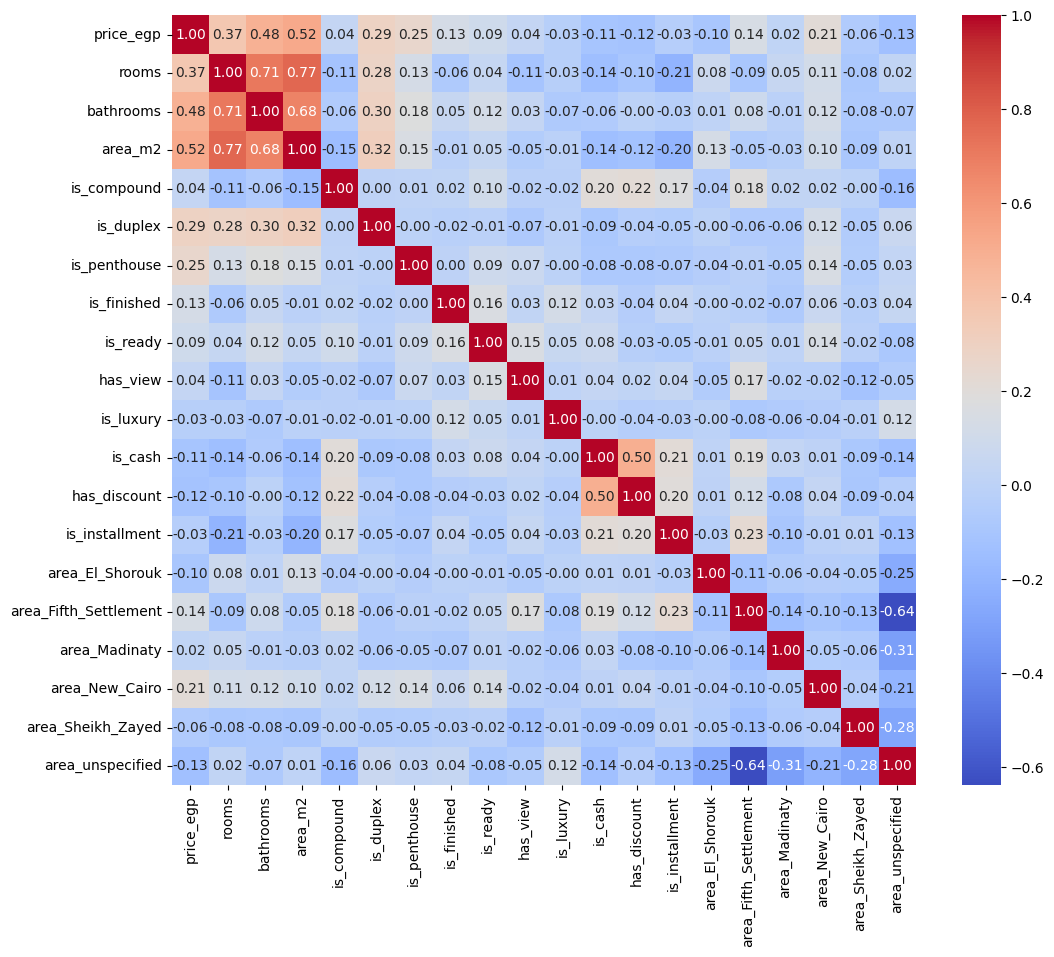

In [34]:
plt.figure(figsize=(12, 10))
sns.heatmap(data_set.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [35]:
data_set.head()

,title,price_egp,rooms,bathrooms,area_m2,link,is_compound,is_duplex,is_penthouse,is_finished,...,is_cash,has_discount,is_installment,area,area_El_Shorouk,area_Fifth_Settlement,area_Madinaty,area_New_Cairo,area_Sheikh_Zayed,area_unspecified
0,شقة متشطبة جاهزة للسكن في Allegria اليجريا بدا...,7000000,4,4,198,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D8...,0,0,0,1,...,0,0,0,unspecified,0,0,0,0,0,1
1,شقه للبيع استلام فورى في كمبوند سراي بسعر الكا...,5600000,3,2,164,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D9...,1,0,0,0,...,1,1,1,New_Cairo,0,0,0,1,0,0
2,شقه للبيع في كمبوند سراي بسعر الكاش استلام فور...,5700000,3,2,169,https://www.dubizzle.com.eg/ad/%D8%B4%D9%82%D9...,1,0,0,0,...,1,1,1,New_Cairo,0,0,0,1,0,0
3,دوبلكس للبيع ياسمين ٦ التجمع الأول,16500000,5,5,440,https://www.dubizzle.com.eg/ad/%D8%AF%D9%88%D8...,0,1,0,0,...,0,0,0,unspecified,0,0,0,0,0,1
4,للبيع شقة 175 متر في السياحية الشمالية الاولى ...,4285000,3,2,175,https://www.dubizzle.com.eg/ad/%D9%84%D9%84%D8...,0,0,0,0,...,0,0,0,unspecified,0,0,0,0,0,1


In [36]:
# Remove unnecessary columns along with the price column from x2
x2 = data_set.drop(columns=["title", "link", "price_egp", "area"])
y2 = data_set["price_egp"]

x2_tr, x2_val, y2_tr, y2_val = train_test_split(x2, y2, train_size=0.8, random_state=42)

In [37]:
#Normalization 
x2_tr_norm = (x2_tr - x2_tr.mean()) / x2_tr.std()
x2_val_norm = (x2_val - x2_tr.mean()) / x2_tr.std()

In [38]:
#Model2 After Add Featuers
model_2 = LinearRegression()
model_2.fit(x2_tr_norm, y2_tr)
pred_2 = model_2.predict(x2_val_norm)

In [39]:
# Evaluating Model 2 (with engineered features) on the validation set using MAE and R²

mae_2 = mean_absolute_error(y2_val, pred_2)
r2_2 = r2_score(y2_val, pred_2)

print(f"MAE: {mae_2:,.2f}")
print(f"R²: {r2_2:.4f}")

MAE: 2,779,604.60
R²: 0.4754


# 3- Make overall conclusion about the project

# 3) 🏁 Overall Conclusion
### Model 1 used only rooms, bathrooms, and area_m2, and achieved R² = 0.4113 with MAE = 2,912,808.80 EGP.
### Model 2 added engineered features (property type, finishing, location, payment terms), improving R² to 0.4754 and reducing MAE to 2,779,604.60 EGP.
### 📈 Adding engineered features improved R² from 0.41 to 0.48.
### 🏠 Area is the strongest price predictor, followed by bathrooms and rooms.
### 🧹 Outliers were checked manually instead of being blindly removed — only one real error was found (row 314).
### ⚠️ R² around 0.48 is limited because key factors like developer name, exact location, and floor number are not present in the data.
### 🚀 Next steps: collect a bigger dataset, add richer location and developer features, and try non-linear models such as Random Forest. ✅